### F-SPDENO 2D — Navier–Stokes ($(X_0, W) \mapsto X$)

Misma idea que el notebook $W\mapsto X$ (leer ese primero: acá los comentarios son más breves),
pero ahora la **condición inicial $\chi_0$ varía** entre muestras.

$$
(\chi_0(x),\,W(t,x)) \;\xrightarrow[\text{Wick}]{}\;
(\chi_0(x),\,\eta(W)) \;\xrightarrow{\text{FNO 2D}}\; \{C_k(x)\}
\;\xrightarrow{\text{Haar}}\; \hat u(t,x)=\sum_k C_k(x)\,\phi_k(t)
$$

**La única diferencia de código con $W\mapsto X$** está en el canal $\chi_0(x_1,x_2)$ de la entrada que lleva el
campo de vorticidad inicial real de cada muestra, en lugar de un canal en cero.

Para referencia, en la Table 2 del paper F-SPDENO pasa de $0.037$ ($W\mapsto X$) a $0.031$ en esta
tarea, mientras que un FNO sin features de ruido se degrada ($0.051 \to 0.073$). Según lo que se estudió, condicionar en el
ruido vía expansión del caos es lo que permite manejar la CI variable y ruido a la vez.

In [ ]:
import math
from math import factorial
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from numpy.polynomial.hermite_e import hermeval

torch.manual_seed(0); np.random.seed(0); torch.set_num_threads(6)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------- CONFIG (idéntica a ns_fspdeno_Wmap; ver comentarios allí) ----------------
KVECS    = [(1, 0), (0, 1), (1, 1), (1, -1), (2, 0), (0, 2)]
TM       = 3
M        = 2
K_HAAR   = 24
WIDTH    = 32
MODES    = 8
N_LAYERS = 6
EPOCHS   = 25
BS       = 20
LR       = 1e-3
WD       = 0.0   
GRAD_CLIP = 1.0
print("device:", device, "| S =", 2 * len(KVECS), "modos espaciales")

device: cpu | S = 12 modos espaciales


In [2]:
# ============ Carga de datos:  chi0 (CI variable), W (ruido), X (vorticidad) ============
data = np.load("ns_train_X0Wmap.npz")
Wtr, Xtr, CItr = data["W_train"], data["X_train"], data["chi0_train"]
Wte, Xte, CIte = data["W_test"],  data["X_test"],  data["chi0_test"]
s   = int(data["s"]); dt = float(data["dt"]); T = float(data["T"])
sigma = float(data["sigma"]); rec = int(data["rec"])
N, Ntp1, _, _ = Wtr.shape; Nt = Ntp1 - 1
dt_rec = T / rec; xg = np.arange(s) / s
tinc = np.arange(Nt) * dt_rec; ssol = np.arange(Ntp1) / Nt
print(f"N={N} Nt={Nt} s={s} T={T} sigma={sigma}")
print("chi0:", CItr.shape, "| Wtr:", Wtr.shape, "| Xtr:", Xtr.shape)


N=400 Nt=50 s=64 T=0.5 sigma=0.01
chi0: (400, 64, 64) | Wtr: (400, 51, 64, 64) | Xtr: (400, 51, 64, 64)


In [ ]:
# ============ Features de Wick 2D idéntico a ns_fspdeno_Wmap) ============

# la CI entra al modelo por su propio canal, no por aquí.
def spatial_modes_2d(kvecs):
    mods = []
    for (k1, k2) in kvecs:
        ph = 2 * np.pi * (k1 * xg[:, None] + k2 * xg[None, :])
        mods.append(math.sqrt(2.0) * np.cos(ph)); mods.append(math.sqrt(2.0) * np.sin(ph))
    return np.stack(mods, 0)
def temporal_base(Tm):
    e = [np.ones_like(tinc) / np.sqrt(T)]; k = 1
    while len(e) < Tm:
        e.append(np.sqrt(2 / T) * np.cos(2 * np.pi * k * tinc / T))
        if len(e) < Tm: e.append(np.sqrt(2 / T) * np.sin(2 * np.pi * k * tinc / T))
        k += 1
    return np.stack(e, 1)
def multi_indices(D, M):
    res = []
    def rec(p, rem):
        if len(p) == D: res.append(tuple(p)); return
        for v in range(rem + 1): rec(p + [v], rem - v)
    rec([], M); return res
def hermite(k, xv):
    c = np.zeros(k + 1); c[k] = 1.0; return hermeval(xv, c)
def wick(xi, alphas, M):
    Nn, D = xi.shape
    H = np.stack([hermite(k, xi) for k in range(M + 1)], 0)
    out = np.empty((Nn, len(alphas)))
    for i, al in enumerate(alphas):
        val = np.ones(Nn); fac = 1
        for d, ad in enumerate(al):
            if ad: val = val * H[ad, :, d]; fac *= factorial(ad)
        out[:, i] = val / math.sqrt(fac)
    return out

Fsp = spatial_modes_2d(KVECS); S = Fsp.shape[0]; E = temporal_base(TM)
def coords_gauss(W):
    dW = np.diff(W, axis=1)
    g = np.einsum("ntij,mij->ntm", dW, Fsp) / (s * s)
    return np.einsum("tj,ntm->nmj", E, g).reshape(len(W), S * TM)
xitr = coords_gauss(Wtr); xite = coords_gauss(Wte)
cmu, csd = xitr.mean(0), xitr.std(0) + 1e-12
xitr, xite = (xitr - cmu) / csd, (xite - cmu) / csd
alphas = multi_indices(S * TM, M)
Ftr = wick(xitr, alphas, M).astype(np.float32); Fte = wick(xite, alphas, M).astype(np.float32)
fmu, fsd = Ftr.mean(0), Ftr.std(0) + 1e-8
Ftr, Fte = (Ftr - fmu) / fsd, (Fte - fmu) / fsd
P = Ftr.shape[1]
print(f"#features de Wick = {P}")

#features de Wick = 703


In [ ]:
# ============ Base de Haar temporal + piso de error E_K ============
def haar_funcs(K, sv):
    funcs = [np.ones_like(sv)]; level = 0
    while len(funcs) < K:
        for m in range(2 ** level):
            if len(funcs) >= K: break
            aa = m / 2 ** level; bb = (m + 1) / 2 ** level; mid = (aa + bb) / 2
            psi = np.zeros_like(sv); psi[(sv >= aa) & (sv < mid)] = 1.0; psi[(sv >= mid) & (sv < bb)] = -1.0
            funcs.append(psi)
        level += 1
    return np.stack(funcs[:K], 1)
def haar_ortonormal(K, sv):
    Phi = haar_funcs(K, sv); Phi = Phi[:, np.linalg.norm(Phi, axis=0) > 1e-12]
    Q, _ = np.linalg.qr(Phi); return Q
Qh = haar_ortonormal(K_HAAR, ssol); Kout = Qh.shape[1]
Cgt = np.einsum("tk,ntij->nkij", Qh, Xtr); Xrec = np.einsum("tk,nkij->ntij", Qh, Cgt)
E_K = (np.linalg.norm((Xtr - Xrec).reshape(N, -1), axis=1) / np.linalg.norm(Xtr.reshape(N, -1), axis=1)).mean()
print(f"K_HAAR={K_HAAR} (rango {Kout}) -> E_K = {E_K:.3e}")

K_HAAR=24 (rango 24) -> E_K = 4.698e-02


In [ ]:
# ============ Entrada del FNO 2D: el canal chi0 lleva la CI real de cada muestra ============
# Esta es la única diferencia real con W->X: [chi0(x) real, x1, x2, features], donde chi0 varía por
# trayectoria. La grilla se comparte y las features se difunden por batch
gx = np.repeat(xg[:, None], s, 1).astype(np.float32)
gy = np.repeat(xg[None, :], s, 0).astype(np.float32)
grid_t = torch.tensor(np.stack([gx, gy], -1)).to(device)           # (s,s,2) compartido
CItr_t = torch.tensor(CItr).to(device); CIte_t = torch.tensor(CIte).to(device)
Ftr_t = torch.tensor(Ftr).to(device);  Fte_t = torch.tensor(Fte).to(device)
Ytr = torch.tensor(Xtr).to(device); Yte = torch.tensor(Xte).to(device)
Qt = torch.tensor(Qh.astype(np.float32)).to(device)
in_c = 3 + P

def make_input(chi0_b, F_b):
    """chi0_b:(b,s,s), F_b:(b,P) -> (b,s,s,in_c) = [chi0, x1, x2, features]."""
    b = chi0_b.shape[0]
    g = grid_t[None].expand(b, s, s, 2)
    ff = F_b[:, None, None, :].expand(b, s, s, P)
    return torch.cat([chi0_b[..., None], g, ff], -1)
print(f"in_c = 1 chi0(real) + 2 grilla + {P} Wick = {in_c}")

in_c = 1 chi0(real) + 2 grilla + 703 Wick = 706


In [ ]:
# ============ FNO 2D + utilidades ============
# ver comentarios en el otro notebook
class SpectralConv2d(nn.Module):
    def __init__(self, ic, oc, m1, m2):
        super().__init__(); self.m1, self.m2 = m1, m2; sc = 1.0 / (ic * oc)
        self.w1 = nn.Parameter(sc * torch.rand(ic, oc, m1, m2, dtype=torch.cfloat))
        self.w2 = nn.Parameter(sc * torch.rand(ic, oc, m1, m2, dtype=torch.cfloat))
    def forward(self, x):
        B, Cc, H, Wd = x.shape; xft = torch.fft.rfft2(x)
        out = torch.zeros(B, self.w1.shape[1], H, Wd // 2 + 1, dtype=torch.cfloat, device=x.device)
        out[:, :, :self.m1, :self.m2]  = torch.einsum("bixy,ioxy->boxy", xft[:, :, :self.m1, :self.m2],  self.w1)
        out[:, :, -self.m1:, :self.m2] = torch.einsum("bixy,ioxy->boxy", xft[:, :, -self.m1:, :self.m2], self.w2)
        return torch.fft.irfft2(out, s=(H, Wd))
class FNO2d(nn.Module):
    def __init__(self, ic, oc, width=32, modes=8, nl=6):
        super().__init__(); self.fc0 = nn.Linear(ic, width)
        self.spec = nn.ModuleList([SpectralConv2d(width, width, modes, modes) for _ in range(nl)])
        self.pw = nn.ModuleList([nn.Conv2d(width, width, 1) for _ in range(nl)])
        self.fc1 = nn.Linear(width, 128); self.fc2 = nn.Linear(128, oc)
    def forward(self, x):
        x = self.fc0(x).permute(0, 3, 1, 2)
        for sp, w in zip(self.spec, self.pw): x = F.gelu(sp(x) + w(x))
        x = x.permute(0, 2, 3, 1); return self.fc2(F.gelu(self.fc1(x)))
def reconstruir(Cf): return torch.einsum("bijk,tk->btij", Cf, Qt)
def rel_l2(p, Y):
    num = torch.linalg.norm((p - Y).reshape(len(Y), -1), dim=1)
    den = torch.linalg.norm(Y.reshape(len(Y), -1), dim=1); return (num / den).mean()
@torch.no_grad()
def eval_batched(CIm, Fm, Y, bs=BS):
    net.eval(); tot = 0
    for i in range(0, len(Fm), bs):
        p = reconstruir(net(make_input(CIm[i:i+bs], Fm[i:i+bs])))
        tot += rel_l2(p, Y[i:i+bs]).item() * len(Y[i:i+bs])
    return tot / len(Fm)
net = FNO2d(in_c, Kout, WIDTH, MODES, N_LAYERS).to(device)
print(f"FNO 2D params: {sum(p.numel() for p in net.parameters()):,}")

FNO 2D params: 822,712


baseline (campo medio) rel_l2 = 0.9190  (alto: la CI variable domina la solución)
época   0: train=1.0032  test=1.0030  lr=1.0e-03
época   5: train=0.3422  test=0.3975  lr=1.0e-03
época  10: train=0.3108  test=0.4141  lr=1.0e-03
época  15: train=0.2168  test=0.4586  lr=5.0e-04
época  20: train=0.1556  test=0.4764  lr=2.5e-04
época  24: train=0.1424  test=0.4925  lr=1.3e-04

MEJOR test = 0.3975


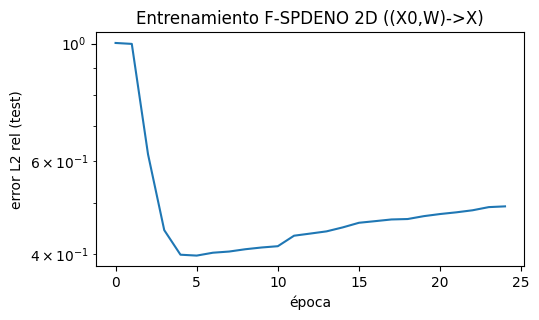

In [ ]:
# ============ Baseline + Entrenamiento ============
# Con CI variable el campo medio de train es un baseline malo (cada solución depende
# fuertemente de su propia CI), que dé cerca de 1 confirma que aquí sí hay un operador
# no trivial que aprender.
base_pred = Ytr.mean(0, keepdim=True).expand_as(Yte)
print(f"baseline (campo medio) rel_l2 = {rel_l2(base_pred, Yte).item():.4f}  "
      f"(alto: la CI variable domina la solución)")
opt = torch.optim.Adam(net.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)
best, hist = float("inf"), []
for ep in range(EPOCHS):
    net.train(); perm = torch.randperm(N)
    for i in range(0, N, BS):
        idx = perm[i:i + BS]; opt.zero_grad()
        loss = rel_l2(reconstruir(net(make_input(CItr_t[idx], Ftr_t[idx]))), Ytr[idx])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP)
        opt.step()
    e_te = eval_batched(CIte_t, Fte_t, Yte); sched.step(e_te); hist.append(e_te)
    if e_te < best: best = e_te; torch.save(net.state_dict(), "ns_best_X0Wmap.pt")
    if ep % 5 == 0 or ep == EPOCHS - 1:
        print(f"época {ep:>3}: train={loss.item():.4f}  test={e_te:.4f}  lr={opt.param_groups[0]['lr']:.1e}")
print(f"\nMEJOR test = {best:.4f}")
fig, ax = plt.subplots(figsize=(5.5, 3.3)); ax.plot(hist); ax.set_yscale("log")
ax.set_xlabel("época"); ax.set_ylabel("error L2 rel (test)")
ax.set_title("Entrenamiento F-SPDENO 2D ((X0,W)->X)")
plt.tight_layout(); plt.savefig("ns_train_X0Wmap.pdf"); plt.show()

Error L2 relativo de TEST ((X0,W)->X): 0.3975
Referencia paper (Table 2, F-SPDENO, (X0,W)->X): 0.031


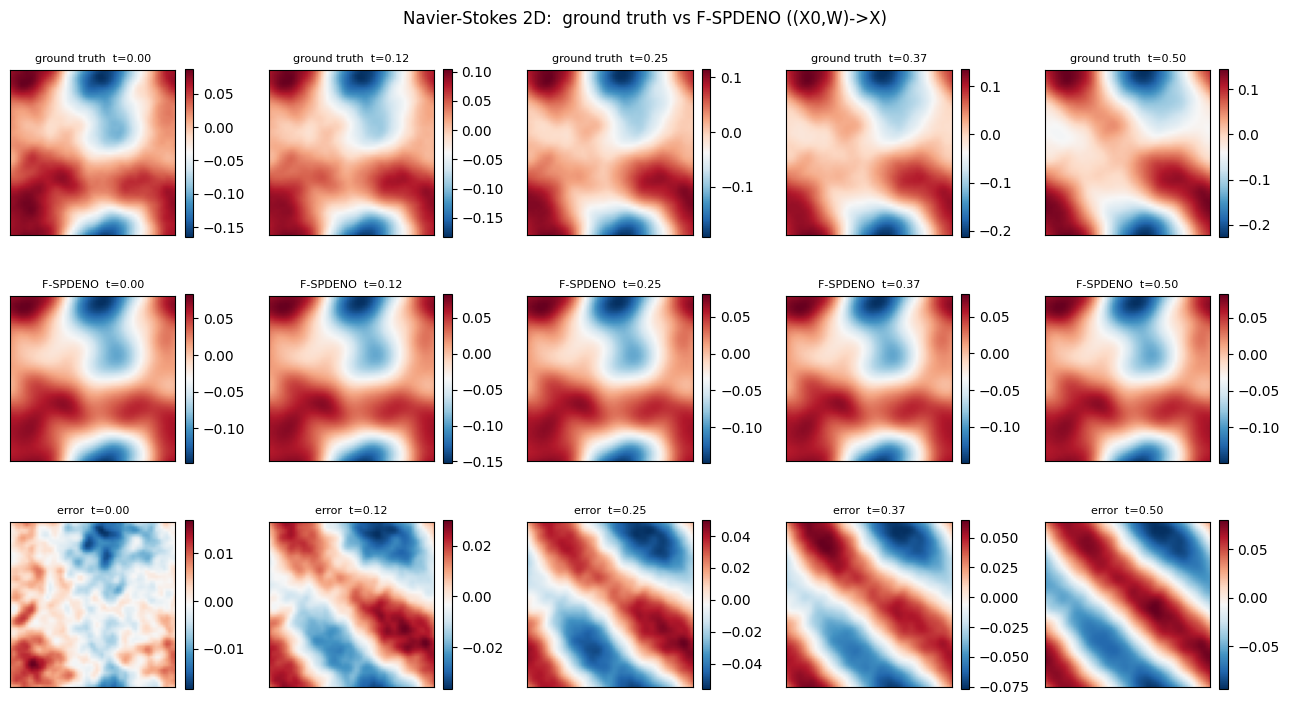

In [8]:
# ============ Evaluación con el mejor checkpoint + figura ============
net.load_state_dict(torch.load("ns_best_X0Wmap.pt")); net.eval()
err = eval_batched(CIte_t, Fte_t, Yte)
print(f"Error L2 relativo de TEST ((X0,W)->X): {err:.4f}")
print("Referencia paper (Table 2, F-SPDENO, (X0,W)->X): 0.031")
with torch.no_grad():
    pred0 = reconstruir(net(make_input(CIte_t[:1], Fte_t[:1])))[0].cpu().numpy()
gt0 = Yte[0].cpu().numpy()
idx = [int(k) for k in np.linspace(0, Nt, 5)]
fig, axs = plt.subplots(3, 5, figsize=(13, 7.2))
for col, ti in enumerate(idx):
    for row, (dat, ttl) in enumerate([(gt0, "ground truth"), (pred0, "F-SPDENO"), (gt0 - pred0, "error")]):
        im = axs[row, col].imshow(dat[ti], origin="lower", cmap="RdBu_r")
        axs[row, col].set_title(f"{ttl}  t={ti*dt_rec:.2f}", fontsize=8)
        axs[row, col].set_xticks([]); axs[row, col].set_yticks([])
        fig.colorbar(im, ax=axs[row, col], fraction=0.046)
plt.suptitle("Navier-Stokes 2D:  ground truth vs F-SPDENO ((X0,W)->X)")
plt.tight_layout(); plt.savefig("ns_pred_X0Wmap.pdf"); plt.show()